# 4.1 MultiLDA — 16바이트 동시 프로파일링

## 이 노트북이 답하는 질문

4.0 은 바이트 하나를 프로파일링했다. 키는 16바이트다. **16번 반복하면 되는가?**

된다. 하지만 그러면 100,000장짜리 파형 배열을 16번 훑는다.
`scalib.modeling.MultiLDA` 는 **파형을 한 번만 읽고** 변수 16개를 동시에 학습한다.

| | |
|---|---|
| 학습 | `/profiling` 100,000장 |
| 공격 | `/attack` 10,000장 → **키 16바이트 전부 복구** |
| 하드웨어 | 불필요. `1.0.SNR` 선행 필요 |

## `LDAClassifier` 와의 관계

| | `LDAClassifier` | `MultiLDA` |
|--|-----------------|------------|
| 변수 | 1개 | `nv` 개 |
| POI | 호출자가 잘라서 넘김 | **`pois` 로 변수마다 지정** |
| 라벨 | `(n,)` | `(n, nv)` |
| `predict_proba` | `(n, nc)` | 변수마다 하나씩, **리스트** |

`pois` 에 바이트마다 다른 창을 줄 수 있다는 점이 중요하다 — 1.0 에서 본 대로
바이트별 누설 지점이 서로 다르기 때문이다.

In [1]:
import sys
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams["font.family"] = "NanumGothic"
matplotlib.rcParams["axes.unicode_minus"] = False

# 공용 정의(AES 상수·데이터셋 로더)는 scalib_common.py 한 곳에만 둔다.
# 노트북마다 복사하면 값을 고칠 곳이 10군데가 되기 때문이다.
sys.path.insert(0, ".")
from scalib_common import SBOX, HW, AES_BLOCK, sbox_out, load_group, dataset_summary

import scalib
print("SCALib :", scalib.__version__)
print()
print(dataset_summary())

SCALib : 0.6.4

측정 조건
  created      2026-08-07T00:34:27
  cipher       AES-128-ECB (tiny-AES-c)
  platform     CW308_STM32F3
  ns           33172
  adc_mul      4
  adc_freq     29537976.0
  clk_hz       7384494.0
  gain_db      25.091743119266056
  trace_scale  32768.0

그룹
  /attack      10000 장 x 33172 샘플   키=fixed 평문=random
  /explore      5000 장 x 33172 샘플   키=random 평문=random
  /profiling   39000 장 x 33172 샘플   키=? 평문=?
  /tvla_fk      1000 장 x 33172 샘플   키=fixed 평문=fixed
  /tvla_rk      1000 장 x 33172 샘플   키=random 평문=fixed


In [2]:
from pathlib import Path

POI_PATH = Path("nb_output/poi.npz")
if not POI_PATH.is_file():
    raise FileNotFoundError(
        "nb_output/poi.npz 가 없다. 1.0.SNR.ipynb 를 먼저 실행한다.\n"
        "프로파일링은 파형 전체가 아니라 누설 지점 주변만 쓰기 때문이다.")
pz = np.load(POI_PATH)
poi, windows = pz["poi"], pz["windows"]

# 16바이트의 창을 모두 덮는 연속 구간을 한 번에 읽는다.
# 흩어진 인덱스로 HDF5 를 읽으면 느리므로, 넓게 읽고 메모리에서 자른다.
LO, HI = int(windows.min()), int(windows.max()) + 1
print("POI 구간 [%d, %d) — %d 샘플, 바이트당 창 %d 샘플" % (LO, HI, HI - LO, windows.shape[1]))

POI 구간 [6025, 6918) — 893 샘플, 바이트당 창 41 샘플


In [3]:
N_PROF = 100000
prof = load_group("profiling", n=N_PROF, samples=slice(LO, HI))
atk = load_group("attack", samples=slice(LO, HI))
TRUE_KEY = np.array(atk["attrs"]["fixed_key"], dtype=np.uint8)

pois = [windows[i] - LO for i in range(AES_BLOCK)]        # 변수마다 다른 창
x_prof = sbox_out(prof["p"], prof["k"]).astype(np.uint16) # (n, 16) — 2차원

print("변수 %d개, 변수당 창 %d 샘플" % (len(pois), len(pois[0])))
print("바이트별 POI:", poi.tolist())

변수 16개, 변수당 창 41 샘플
바이트별 POI: [6045, 6277, 6509, 6741, 6097, 6329, 6561, 6793, 6149, 6381, 6613, 6845, 6201, 6433, 6665, 6897]


---
## 1. 학습

| 단계 | 코드 |
|:----:|------|
| 생성 | `mlda = MultiLDA(ncs=[256]*16, ps=[8]*16, pois=pois)` |
| 누적 | `mlda.fit_u(traces, x)` — `traces` 는 **자르지 않은 전체 구간** |
| 완료 | `mlda.solve()` |
| 판정 | `mlda.predict_proba(traces)` → 길이 16 리스트 |

`fit_u` 에 넘기는 `traces` 는 POI 로 자르지 않는다 — `pois` 가 이미 어느 열을 볼지 알고 있다.

> **라벨 shape 규약이 API 마다 다르다.** 문서에 정리되어 있지 않고 실행해 봐야 알 수 있어
> 여기 적어 둔다. 틀리면 `ValueError: The classes array has N dimensions` 가 난다.
>
> | API | 라벨 shape | dtype |
> |-----|-----------|-------|
> | `Ttest` | `(n,)` | `uint16` |
> | `SNR`, `Cpa`, `MultiLDA` | `(n, nv)` | `uint16` |
> | `LDAClassifier` | `(n,)` | `uint16` |
> | `RLDAClassifier` | `(n, nv)` | `uint64` |
> | `RLDAInformationEstimator` | `(n,)` | `uint64` |
>
> 파형(`traces`)은 어디서나 `(n, ns)` `int16` 이다.

In [4]:
from scalib.modeling import MultiLDA
import time

P_DIM = 8
t0 = time.time()
mlda = MultiLDA(ncs=[256] * AES_BLOCK, ps=[P_DIM] * AES_BLOCK, pois=pois)
mlda.fit_u(np.ascontiguousarray(prof["t"]), x_prof)
mlda.solve()
print("16변수 동시 학습: %.1f 초" % (time.time() - t0))

16변수 동시 학습: 0.1 초


---
## 2. 키 16바이트 복구

변수마다 확률을 받아, 4.0 과 같은 방식으로 로그확률을 누적한다.

In [5]:
probas = mlda.predict_proba(np.ascontiguousarray(atk["t"]))     # 리스트 길이 16
print("predict_proba → %d개, 각 %s" % (len(probas), probas[0].shape))

GUESS = np.arange(256, dtype=np.uint8)

def key_scores(proba, plaintexts, n_use):
    lp = np.log(np.maximum(proba[:n_use], 1e-300))
    g = SBOX[np.bitwise_xor(plaintexts[:n_use, None], GUESS[None, :])]
    return np.take_along_axis(lp, g, axis=1).sum(axis=0)

N_USE = 200
scores = np.stack([key_scores(probas[i], atk["p"][:, i], N_USE) for i in range(AES_BLOCK)])
recovered = scores.argmax(axis=1).astype(np.uint8)
ranks = np.array([(scores[i] > scores[i, TRUE_KEY[i]]).sum() for i in range(AES_BLOCK)])
ok = recovered == TRUE_KEY

print()
print("바이트  복구  정답  순위   판정")
for i in range(AES_BLOCK):
    print("  %2d     %02x    %02x    %3d     %s" % (i, recovered[i], TRUE_KEY[i], ranks[i],
                                                    "O" if ok[i] else "X"))
print()
print("복구: " + " ".join("%02x" % b for b in recovered))
print("정답: " + " ".join("%02x" % b for b in TRUE_KEY))
print("=== %d장 사용, %d/16 바이트 일치 — %s ===" % (N_USE, ok.sum(), "성공" if ok.all() else "실패"))

predict_proba → 16개, 각 (10000, 256)

바이트  복구  정답  순위   판정
   0     2f    2f      0     O
   1     6b    6b      0     O
   2     07    07      0     O
   3     31    31      0     O
   4     d3    d3      0     O
   5     e2    e2      0     O
   6     66    66      0     O
   7     7f    7f      0     O
   8     26    26      0     O
   9     85    85      0     O
  10     42    42      0     O
  11     9f    9f      0     O
  12     35    35      0     O
  13     dc    dc      0     O
  14     5d    5d      0     O
  15     d1    d1      0     O

복구: 2f 6b 07 31 d3 e2 66 7f 26 85 42 9f 35 dc 5d d1
정답: 2f 6b 07 31 d3 e2 66 7f 26 85 42 9f 35 dc 5d d1
=== 200장 사용, 16/16 바이트 일치 — 성공 ===


### 몇 장이면 16바이트가 다 맞는가

In [6]:
print("장수    맞은 바이트   순위 합계(작을수록 좋음)")
hist = []
for m in (1, 2, 5, 10, 20, 50, 100, 200):
    sc = np.stack([key_scores(probas[i], atk["p"][:, i], m) for i in range(AES_BLOCK)])
    r = np.array([(sc[i] > sc[i, TRUE_KEY[i]]).sum() for i in range(AES_BLOCK)])
    hit = int((sc.argmax(axis=1).astype(np.uint8) == TRUE_KEY).sum())
    hist.append((m, hit, int(r.sum())))
    print("%5d      %2d / 16      %6d %s" % (m, hit, r.sum(), "★" if hit == 16 else ""))

장수    맞은 바이트   순위 합계(작을수록 좋음)
    1       4 / 16          92 
    2      12 / 16          10 
    5      16 / 16           0 ★
   10      16 / 16           0 ★
   20      16 / 16           0 ★
   50      16 / 16           0 ★
  100      16 / 16           0 ★


  200      16 / 16           0 ★


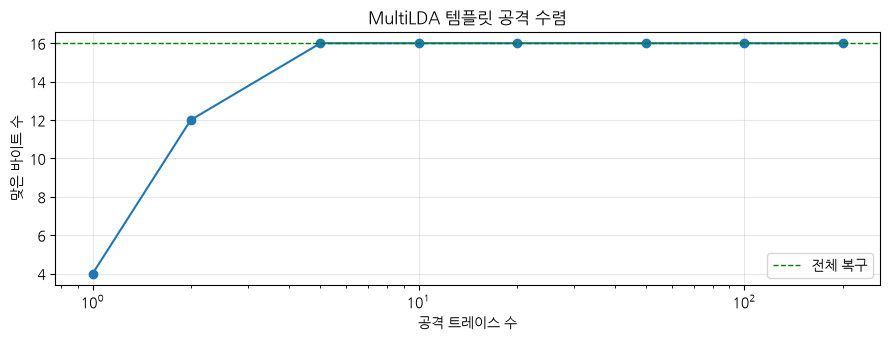

In [7]:
ms = [h[0] for h in hist]
plt.figure(figsize=(9, 3.5))
plt.plot(ms, [h[1] for h in hist], "o-")
plt.axhline(16, color="g", ls="--", lw=1, label="전체 복구")
plt.xscale("log"); plt.xlabel("공격 트레이스 수"); plt.ylabel("맞은 바이트 수")
plt.title("MultiLDA 템플릿 공격 수렴")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

---
## 3. CPA 와 비교

같은 공격 데이터에서 3.0 CPA 는 몇 장이 필요했는지와 견주면 프로파일링의 값어치가 보인다.
프로파일링은 **미리 100,000장을 쓴 대가로** 공격 시 훨씬 적은 장수로 끝난다.

In [8]:
from scalib.attacks import Cpa

model_1d = HW[SBOX[np.arange(256)]].astype(np.float64)
seg_atk = np.ascontiguousarray(atk["t"])
models = np.broadcast_to(model_1d[None, :, None],
                         (AES_BLOCK, 256, seg_atk.shape[1])).copy()

print("장수    CPA 맞은 바이트   MultiLDA 맞은 바이트")
for m in (10, 50, 200, 1000):
    c = Cpa(nc=256, kind=Cpa.IntermediateKind.Xor)
    c.fit_u(seg_atk[:m], atk["p"][:m].astype(np.uint16))
    cpa_hit = int((np.nanmax(np.abs(c.get_correlation(models)), axis=2).argmax(axis=1).astype(np.uint8)
                   == TRUE_KEY).sum())
    sc = np.stack([key_scores(probas[i], atk["p"][:, i], m) for i in range(AES_BLOCK)])
    lda_hit = int((sc.argmax(axis=1).astype(np.uint8) == TRUE_KEY).sum())
    print("%5d          %2d / 16              %2d / 16" % (m, cpa_hit, lda_hit))

장수    CPA 맞은 바이트   MultiLDA 맞은 바이트
   10           0 / 16              16 / 16
   50           9 / 16              16 / 16
  200          16 / 16              16 / 16


 1000          16 / 16              16 / 16


---
## 4. 요약

| 항목 | 내용 |
|------|------|
| 목적 | 여러 변수를 **파형 한 번 읽기로** 동시에 프로파일링한다 |
| API | `MultiLDA(ncs, ps, pois)` → `fit_u(traces, x)` → `solve()` → `predict_proba(traces)` |
| `pois` | 변수마다 볼 열 인덱스. 바이트별 누설 위치가 다르므로 필요하다 |
| `x` | `(n, nv)` `uint16` — **2차원**. `LDAClassifier` 와 다르다 |
| 출력 | 길이 `nv` 리스트, 각 `(n, nc)` |

### 실패 시 점검

1. `fit_u` 에 POI 로 자른 파형을 넣으면 안 된다. `pois` 인덱스와 어긋난다.
2. 특정 바이트만 계속 틀린다 → 그 바이트의 POI 를 1.0 에서 다시 확인한다.

다음: `4.2.RLDA.ipynb` — 회귀 기반 모델과 정보량 추정.